Conditional Edge

In [7]:
from typing import TypedDict,Literal
from langgraph.graph import StateGraph,START,END

class NumberState(TypedDict):
    number:int
    result:str


def receive_number(state: NumberState) -> dict:
    # Entry node - just prints and passes the number through unchanged.
    print(f"  Received number: {state['number']}")
    return {}


def route_even_or_odd(state: NumberState) -> Literal["even", "odd"]:
    # Return 'even' or 'odd' based on the number in state.
    if state["number"] % 2 == 0:
        return "even"
    else:
        return "odd"

def even_node(state:NumberState)->dict:
    msg=f"{state["number"]} is Even"
    print(f"[even_node] {msg}")
    return {"result":msg}

def odd_node(state:NumberState)->dict:
    msg=f"{state["number"]} is odd"
    print(f"[odd_node] {msg}")
    return {"result":msg}

In [21]:
builder=StateGraph(NumberState)

In [22]:
builder.add_node("receive",receive_number)
builder.add_node("odd_node",even_node)
builder.add_node("even_node",even_node)

builder.add_edge(START,"receive")
builder.add_conditional_edges(
    "receive",route_even_or_odd,
    {
        "even":"even_node",
        "odd":"odd_node"
    }
)
builder.add_edge("even_node",END)
builder.add_edge("odd_node",END)

graph=builder.compile()

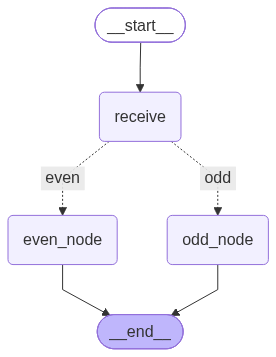

In [23]:
from IPython.display import Image,display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [52]:
from typing import TypedDict,Literal
from langgraph.graph import StateGraph, START,END

In [53]:
class TaskState(TypedDict):
    tasktype:str
    input:str
    output:str

In [54]:
from ast import List
def decision(state:TaskState)->Literal["Mathworker","textworker","fallback"]:
    task = state["tasktype"].strip().lower()
    if task=="math":
        return "Mathworker"
    elif task=="text":
        return "textworker"
    else:
        return "fallback"


In [55]:

def Mathworker(state:TaskState)->dict:
    try:
        result=str(eval(state["input"]))
    except Exception:
        result="math error"
    print(f"[math_worker] {state["input"]}: {result}")
    return {"output":result}

def textworker(state:TaskState)->dict:
    result=state["input"].upper()
    print(f"[text_worker] {state["input"]}: {result}")
    return {"output":result}

def fallback(state:TaskState)->dict:
    result=f"Unknown text type : {state["tasktype"]}"
    print(f"[fallback]: {result}")
    return {"output":result}



In [56]:

builder=StateGraph(TaskState)

builder.add_node("mathworker",Mathworker)
builder.add_node("textworker",textworker)
builder.add_node("fallback",fallback)

out_des={
    "Mathworker":"mathworker",
    "textworker":"textworker",
    "fallback":"fallback"
}

builder.add_conditional_edges(
    START,
    decision,
    out_des,
)

builder.add_edge("mathworker",END)
builder.add_edge("textworker",END)
builder.add_edge("fallback",END)

In [57]:
graph=builder.compile()

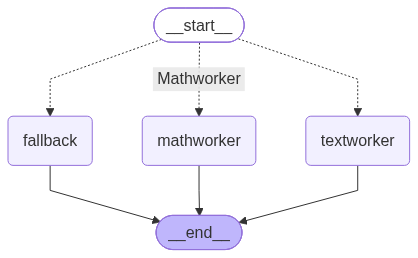

In [63]:
from IPython.display import Image,display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [64]:
tasks = [
    {"tasktype": "math", "input": "3 * 7 + 2", "output": ""},
    {"tasktype": "text", "input": "hello world", "output": ""},
    {"tasktype": "unknown", "input": "do something", "output": ""},
]

In [65]:
for task in tasks:
    print(f"Task: {task['tasktype']}")
    out = graph.invoke(task)
    print(f"  Result: {out['output']}")
    print()

Task: math
[math_worker] 3 * 7 + 2: 23
  Result: 23

Task: text
[text_worker] hello world: HELLO WORLD
  Result: HELLO WORLD

Task: unknown
[fallback]: Unknown text type : unknown
  Result: Unknown text type : unknown

